In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import corner
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from itertools import combinations_with_replacement

In [2]:
plt.rcParams['figure.max_open_warning'] = 0
    
plt.rcParams['mathtext.fontset']  = 'stix'
plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

### Initialization

In [3]:
df = pd.read_csv('../src/data/SXS_Parameters_non-spinning.csv')
df.set_index('ID', inplace=True)
masks = df['catalog'] == 'SXS'
sxs_ids = df.index
chi = df.loc[sxs_ids, 'chieff'].values
nu = df.loc[sxs_ids, 'nu'].values
ecc = df.loc[sxs_ids, 'ecc'].values
emrg = df.loc[sxs_ids, 'Heff_til'].values
bmrg = df.loc[sxs_ids, 'b_massless_EOB'].values
jmrg = df.loc[sxs_ids, 'Jmrg_til'].values
sxs_ids = [f"{int(i):04d}" for i in sxs_ids]

In [4]:
c2A, c3A, c2p, c3p, c4p = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
c2A_err, c3A_err, c2p_err, c3p_err, c4p_err = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
full_data = []
for i, sxs_id in enumerate(sxs_ids):
    try:
        try:
            log_L_1 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_1/Algorithm/Evidence.txt')[1]
        except:
            log_L_1 = -np.inf
        try:
            log_L_2 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_2/Algorithm/Evidence.txt')[1]
        except:
            log_L_2 = -np.inf
        try:
            log_L_3 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_3/Algorithm/Evidence.txt')[1]
        except:
            log_L_3 = -np.inf
        max_id = np.argmax([np.median(log_L_1), np.median(log_L_2), np.median(log_L_3)])
        data = np.loadtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_{max_id+1}/Algorithm/posterior.dat')[:,[4,1,5,2,3]]
        c2A[i], c3A[i], c2p[i], c3p[i], c4p[i] = np.median(data, axis=0)
        c2A_err[i], c3A_err[i], c2p_err[i], c3p_err[i], c4p_err[i] = np.std(data, axis=0)
        full_data.append(data)
    except:
        continue

### Mismatches

In [5]:
mismatch = np.zeros(len(sxs_ids))
for i, sxs_id in enumerate(sxs_ids):
    try:
        try:
            log_L_1 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_1/Algorithm/Evidence.txt')[1]
        except:
            log_L_1 = -np.inf
        try:
            log_L_2 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_2/Algorithm/Evidence.txt')[1]
        except:
            log_L_2 = -np.inf
        try:
            log_L_3 = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_3/Algorithm/Evidence.txt')[1]
        except:
            log_L_3 = -np.inf
        max_id = np.argmax([np.median(log_L_1), np.median(log_L_2), np.median(log_L_3)])
        mismatch_row = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}_{max_id+1}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
        mismatch[i] = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0]
    except:
        continue

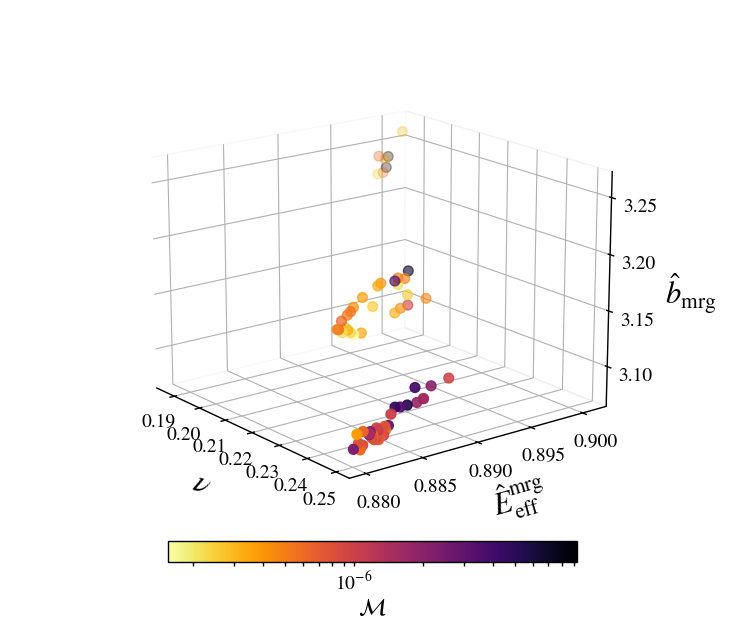

In [6]:
cmap = matplotlib.colormaps.get_cmap('inferno_r')
fig = plt.figure(figsize=(12*1.1,7*1.1))
ax  = fig.add_subplot(111, projection='3d')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
p = ax.scatter(nu, emrg, bmrg, c=mismatch, s=200, marker = '.', cmap=cmap, zorder=-1, norm=LogNorm(vmin=np.min(mismatch[mismatch > 0]), vmax=np.max(mismatch)))
ax.set_xlabel('$\\nu$', fontsize=22, labelpad=12)
ax.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$', fontsize=22, labelpad=12)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel('$\\hat{b}_{\\rm mrg}$', fontsize=22, labelpad=12, rotation=0)
plt.rcParams['mathtext.fontset']  = 'stix'
plt.rcParams['font.family']       = 'STIXGeneral'
cb1 = fig.colorbar(p, pad=0.0, ax=ax, orientation='horizontal', shrink=0.4)
cb1.set_label(label='$\\mathcal{M}$', fontsize=int(22*0.8))
ax.view_init(azim=-38, elev=17)
ax.set_title(" " * 100)
#plt.savefig(f'nc_mismatches_nu_emrg_bmrg.pdf', bbox_inches='tight')
plt.show()

#### Single Parameter

In [7]:
def mismatches_single(parameter):
    mismatches_rit = []
    for order in [1,2,3]:
        mismatch_rit = []
        for i, sxs_id in enumerate(sxs_ids):
            try:
                mismatch_row = np.genfromtxt(f'../src/output/nc_global_fits_sxs_non-spinning/single/nc_global_fits_{parameter}_{order}_sxs_non-spinning/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
                mismatch_rit.append(mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0])
            except:
                mismatch_rit.append(np.nan)
        mismatches_rit.append(mismatch_rit)
    return mismatches_rit

In [8]:
mismatch_global_nu = mismatches_single('nu')
mismatch_global_ecc = mismatches_single('ecc')
mismatch_global_jmrg = mismatches_single('jmrg')
mismatch_global_emrg = mismatches_single('emrg')
mismatch_global_bmrg = mismatches_single('bmrg')

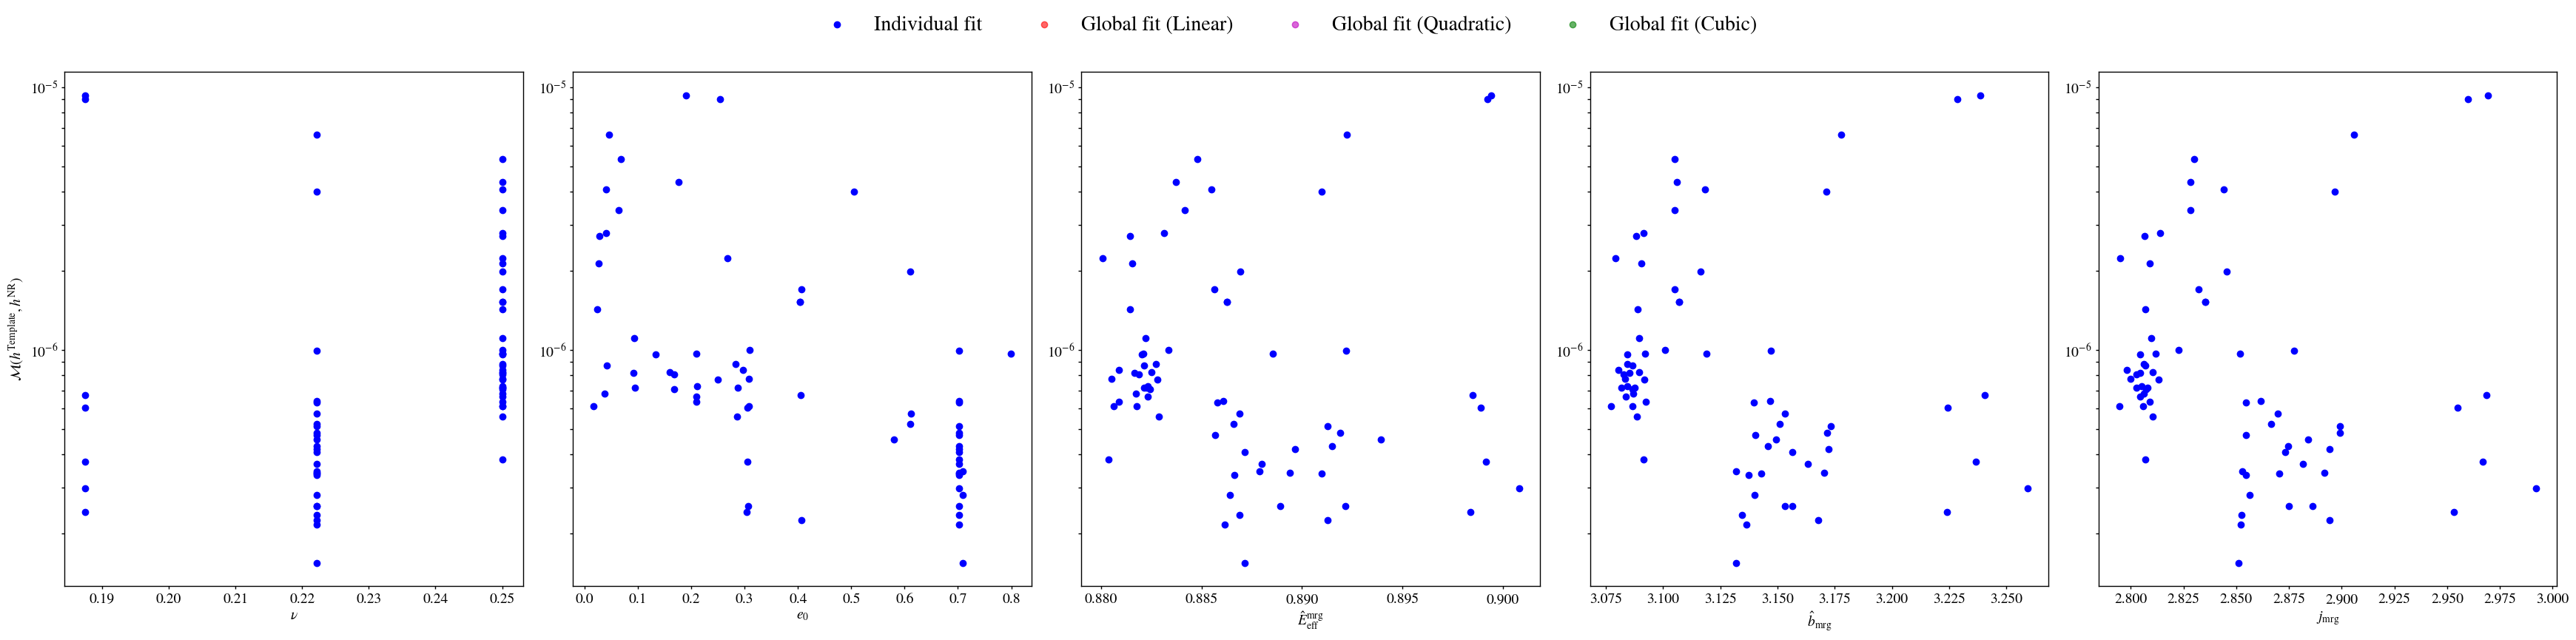

In [9]:
fig, ax = plt.subplots(1, 5, figsize=(35, 8))
ax[0].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0].scatter(nu, mismatch_global_nu[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0].scatter(nu, mismatch_global_nu[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0].scatter(nu, mismatch_global_nu[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0].set_xlabel('$\\nu$')
ax[0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[0].set_yscale('log')
ax[1].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[1].scatter(ecc, mismatch_global_ecc[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1].scatter(ecc, mismatch_global_ecc[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1].scatter(ecc, mismatch_global_ecc[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1].set_xlabel('$e_0$')
ax[1].set_yscale('log')
ax[2].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[2].scatter(emrg, mismatch_global_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2].scatter(emrg, mismatch_global_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2].scatter(emrg, mismatch_global_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[2].set_yscale('log')
ax[3].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[3].scatter(bmrg, mismatch_global_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[3].scatter(bmrg, mismatch_global_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[3].scatter(bmrg, mismatch_global_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[3].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[3].set_yscale('log')
ax[4].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[4].scatter(jmrg, mismatch_global_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[4].scatter(jmrg, mismatch_global_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[4].scatter(jmrg, mismatch_global_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[4].set_xlabel('$j_{{\\rm mrg}}$')
ax[4].set_yscale('log')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=20, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
plt.show()

#### Dual Parameter

In [10]:
def mismatches_dual(parameter):
    mismatches_rit = []
    for order in [1,2,3]:
        mismatch_rit = []
        for i, sxs_id in enumerate(sxs_ids):
            try:
                mismatch_row = np.genfromtxt(f'../src/output/nc_global_fits_sxs_non-spinning/dual/nc_global_fits_{parameter}_{order}_sxs_non-spinning/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
                mismatch_rit.append(mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0])
            except:
                mismatch_rit.append(np.nan)
        mismatches_rit.append(mismatch_rit)
    return mismatches_rit

In [11]:
mismatch_global_ecc_bmrg = mismatches_dual('ecc_bmrg')
mismatch_global_ecc_jmrg = mismatches_dual('ecc_jmrg')
mismatch_global_ecc_emrg = mismatches_dual('ecc_emrg')
mismatch_global_bmrg_jmrg = mismatches_dual('bmrg_jmrg')
mismatch_global_bmrg_emrg = mismatches_dual('bmrg_emrg')
mismatch_global_emrg_jmrg = mismatches_dual('emrg_jmrg')

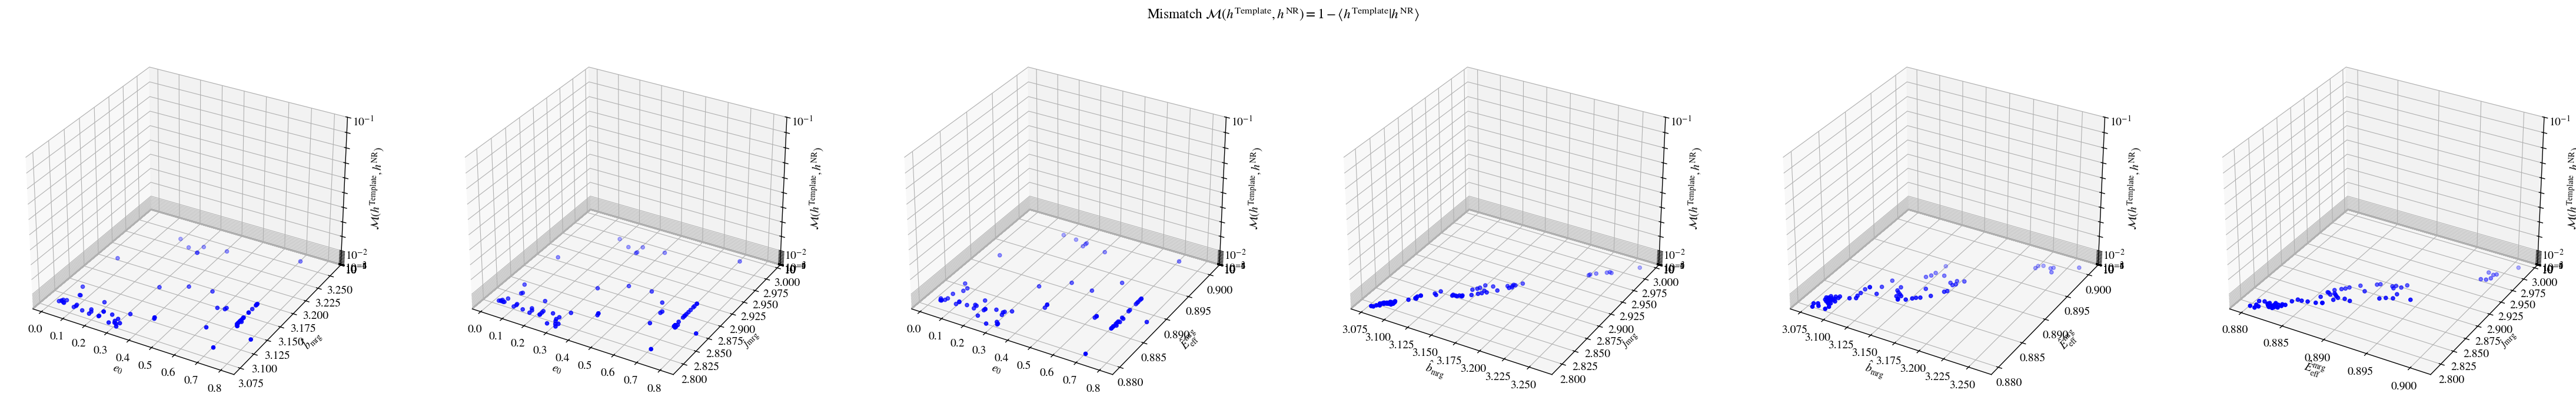

In [12]:
fig = plt.figure(figsize=(45, 7))
ax1 = fig.add_subplot(161, projection='3d')
ax1.scatter(ecc, bmrg, mismatch, color='b', label='Individual fit')
ax1.scatter(ecc, bmrg, mismatch_global_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax1.scatter(ecc, bmrg, mismatch_global_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax1.scatter(ecc, bmrg, mismatch_global_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax1.set_xlabel('$e_0$')
ax1.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax1.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax1.set_zlim3d(1e-7, 1e-1)
ax1.set_zscale('log')
ax2 = fig.add_subplot(162, projection='3d')
ax2.scatter(ecc, jmrg, mismatch, color='b', label='Individual fit')
ax2.scatter(ecc, jmrg, mismatch_global_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax2.scatter(ecc, jmrg, mismatch_global_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax2.scatter(ecc, jmrg, mismatch_global_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax2.set_xlabel('$e_0$')
ax2.set_ylabel('$j_{\\rm mrg}$')
ax2.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax2.set_zlim3d(1e-7, 1e-1)
ax2.set_zscale('log')
ax3 = fig.add_subplot(163, projection='3d')
ax3.scatter(ecc, emrg, mismatch, color='b', label='Individual fit')
ax3.scatter(ecc, emrg, mismatch_global_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax3.scatter(ecc, emrg, mismatch_global_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax3.scatter(ecc, emrg, mismatch_global_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax3.set_xlabel('$e_0$')
ax3.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax3.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax3.set_zlim3d(1e-7, 1e-1)
ax3.set_zscale('log')
ax4 = fig.add_subplot(164, projection='3d')
ax4.scatter(bmrg, jmrg, mismatch, color='b', label='Individual fit')
ax4.scatter(bmrg, jmrg, mismatch_global_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax4.scatter(bmrg, jmrg, mismatch_global_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax4.scatter(bmrg, jmrg, mismatch_global_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax4.set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax4.set_ylabel('$j_{\\rm mrg}$')
ax4.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax4.set_zlim3d(1e-7, 1e-1)
ax4.set_zscale('log')
ax5 = fig.add_subplot(165, projection='3d')
ax5.scatter(bmrg, emrg, mismatch, color='b', label='Individual fit')
ax5.scatter(bmrg, emrg, mismatch_global_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax5.scatter(bmrg, emrg, mismatch_global_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax5.scatter(bmrg, emrg, mismatch_global_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax5.set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax5.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax5.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax5.set_zlim3d(1e-7, 1e-1)
ax5.set_zscale('log')
ax6 = fig.add_subplot(166, projection='3d')
ax6.scatter(emrg, jmrg, mismatch, color='b', label='Individual fit')
ax6.scatter(emrg, jmrg, mismatch_global_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax6.scatter(emrg, jmrg, mismatch_global_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax6.scatter(emrg, jmrg, mismatch_global_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax6.set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax6.set_ylabel('$j_{\\rm mrg}$')
ax6.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax6.set_zlim3d(1e-7, 1e-1)
ax6.set_zscale('log')
plt.suptitle('Mismatch $\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})=1-\\langle h^{\\rm Template}| h^{\\rm NR}\\rangle$')
plt.tight_layout()
plt.show()

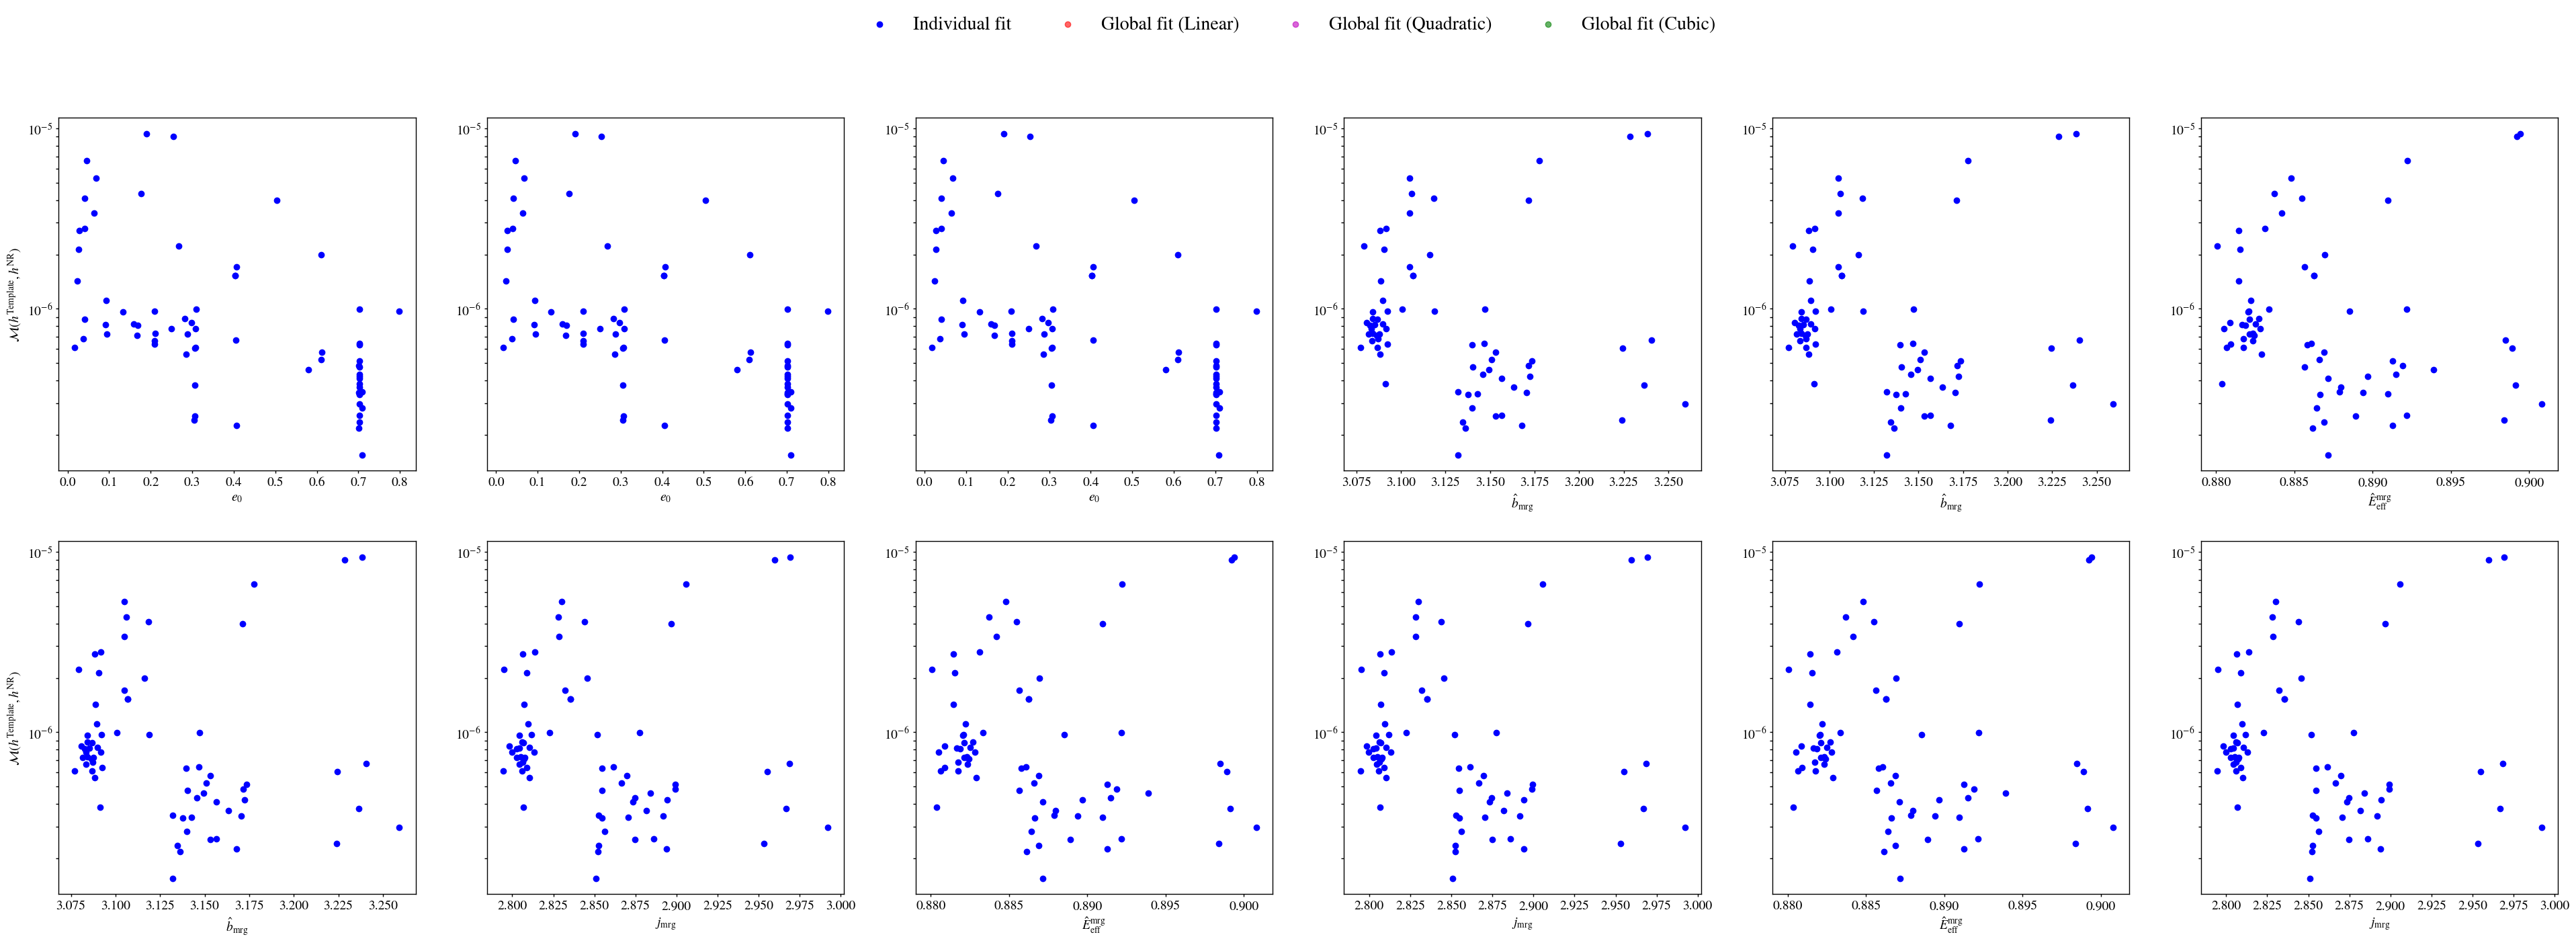

In [13]:
fig, ax = plt.subplots(2, 6, figsize=(48, 15))
ax[0,0].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[0,0].scatter(ecc, mismatch_global_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,0].scatter(ecc, mismatch_global_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,0].scatter(ecc, mismatch_global_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,0].set_xlabel('$e_0$')
ax[0,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[0,0].set_yscale('log')
ax[1,0].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[1,0].scatter(bmrg, mismatch_global_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,0].scatter(bmrg, mismatch_global_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,0].scatter(bmrg, mismatch_global_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,0].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[1,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[1,0].set_yscale('log')
ax[0,1].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[0,1].scatter(ecc, mismatch_global_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,1].scatter(ecc, mismatch_global_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,1].scatter(ecc, mismatch_global_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,1].set_xlabel('$e_0$')
ax[0,1].set_yscale('log')
ax[1,1].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[1,1].scatter(jmrg, mismatch_global_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,1].scatter(jmrg, mismatch_global_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,1].scatter(jmrg, mismatch_global_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,1].set_xlabel('$j_{\\rm mrg}$')
ax[1,1].set_yscale('log')
ax[0,2].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[0,2].scatter(ecc, mismatch_global_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,2].scatter(ecc, mismatch_global_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,2].scatter(ecc, mismatch_global_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,2].set_xlabel('$e_0$')
ax[0,2].set_yscale('log')
ax[1,2].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[1,2].scatter(emrg, mismatch_global_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,2].scatter(emrg, mismatch_global_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,2].scatter(emrg, mismatch_global_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,2].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[1,2].set_yscale('log')
ax[0,3].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[0,3].scatter(bmrg, mismatch_global_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,3].scatter(bmrg, mismatch_global_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,3].scatter(bmrg, mismatch_global_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,3].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[0,3].set_yscale('log')
ax[1,3].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[1,3].scatter(jmrg, mismatch_global_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,3].scatter(jmrg, mismatch_global_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,3].scatter(jmrg, mismatch_global_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,3].set_xlabel('$j_{\\rm mrg}$')
ax[1,3].set_yscale('log')
ax[0,4].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[0,4].scatter(bmrg, mismatch_global_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,4].scatter(bmrg, mismatch_global_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,4].scatter(bmrg, mismatch_global_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,4].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[0,4].set_yscale('log')
ax[1,4].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[1,4].scatter(emrg, mismatch_global_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,4].scatter(emrg, mismatch_global_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,4].scatter(emrg, mismatch_global_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,4].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[1,4].set_yscale('log')
ax[0,5].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[0,5].scatter(emrg, mismatch_global_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,5].scatter(emrg, mismatch_global_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,5].scatter(emrg, mismatch_global_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,5].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[0,5].set_yscale('log')
ax[1,5].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[1,5].scatter(jmrg, mismatch_global_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,5].scatter(jmrg, mismatch_global_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,5].scatter(jmrg, mismatch_global_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,5].set_xlabel('$j_{\\rm mrg}$')
ax[1,5].set_yscale('log')
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=20)
plt.show()

In [14]:
mismatch_global_nu_ecc = mismatches_dual('nu_ecc')
mismatch_global_nu_bmrg = mismatches_dual('nu_bmrg')
mismatch_global_nu_jmrg = mismatches_dual('nu_jmrg')
mismatch_global_nu_emrg = mismatches_dual('nu_emrg')

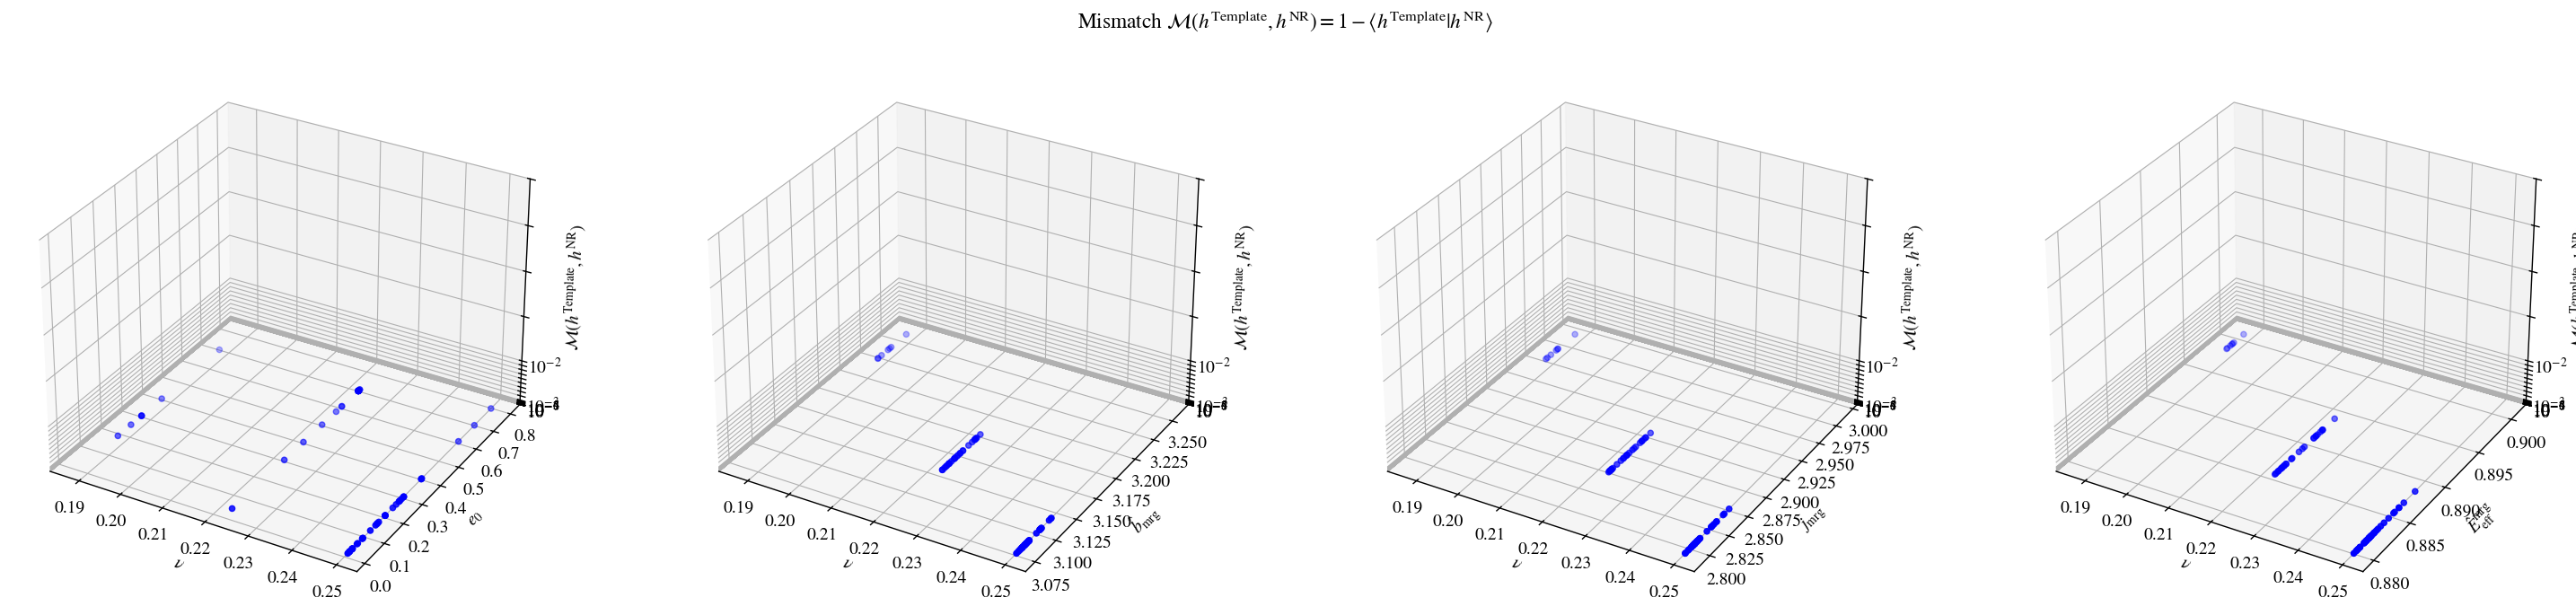

In [15]:
fig = plt.figure(figsize=(30, 7))
ax1 = fig.add_subplot(141, projection='3d')
ax1.scatter(nu, ecc, mismatch, color='b', label='Individual fit')
ax1.scatter(nu, ecc, mismatch_global_nu_ecc[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax1.scatter(nu, ecc, mismatch_global_nu_ecc[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax1.scatter(nu, ecc, mismatch_global_nu_ecc[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax1.set_xlabel('$\\nu$')
ax1.set_ylabel('$e_0$')
ax1.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax1.set_zlim3d(1e-7, 5e-2)
ax1.set_zscale('log')
ax2 = fig.add_subplot(142, projection='3d')
ax2.scatter(nu, bmrg, mismatch, color='b', label='Individual fit')
ax2.scatter(nu, bmrg, mismatch_global_nu_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax2.scatter(nu, bmrg, mismatch_global_nu_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax2.scatter(nu, bmrg, mismatch_global_nu_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax2.set_xlabel('$\\nu$')
ax2.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax2.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax2.set_zlim3d(1e-7, 5e-2)
ax2.set_zscale('log')
ax3 = fig.add_subplot(143, projection='3d')
ax3.scatter(nu, jmrg, mismatch, color='b', label='Individual fit')
ax3.scatter(nu, jmrg, mismatch_global_nu_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax3.scatter(nu, jmrg, mismatch_global_nu_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax3.scatter(nu, jmrg, mismatch_global_nu_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax3.set_xlabel('$\\nu$')
ax3.set_ylabel('$j_{\\rm mrg}$')
ax3.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax3.set_zlim3d(1e-7, 5e-2)
ax3.set_zscale('log')
ax4 = fig.add_subplot(144, projection='3d')
ax4.scatter(nu, emrg, mismatch, color='b', label='Individual fit')
ax4.scatter(nu, emrg, mismatch_global_nu_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax4.scatter(nu, emrg, mismatch_global_nu_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax4.scatter(nu, emrg, mismatch_global_nu_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax4.set_xlabel('$\\nu$')
ax4.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax4.set_zlabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax4.set_zlim3d(1e-7, 5e-2)
ax4.set_zscale('log')
plt.suptitle('Mismatch $\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})=1-\\langle h^{\\rm Template}| h^{\\rm NR}\\rangle$')
plt.tight_layout()
plt.show()

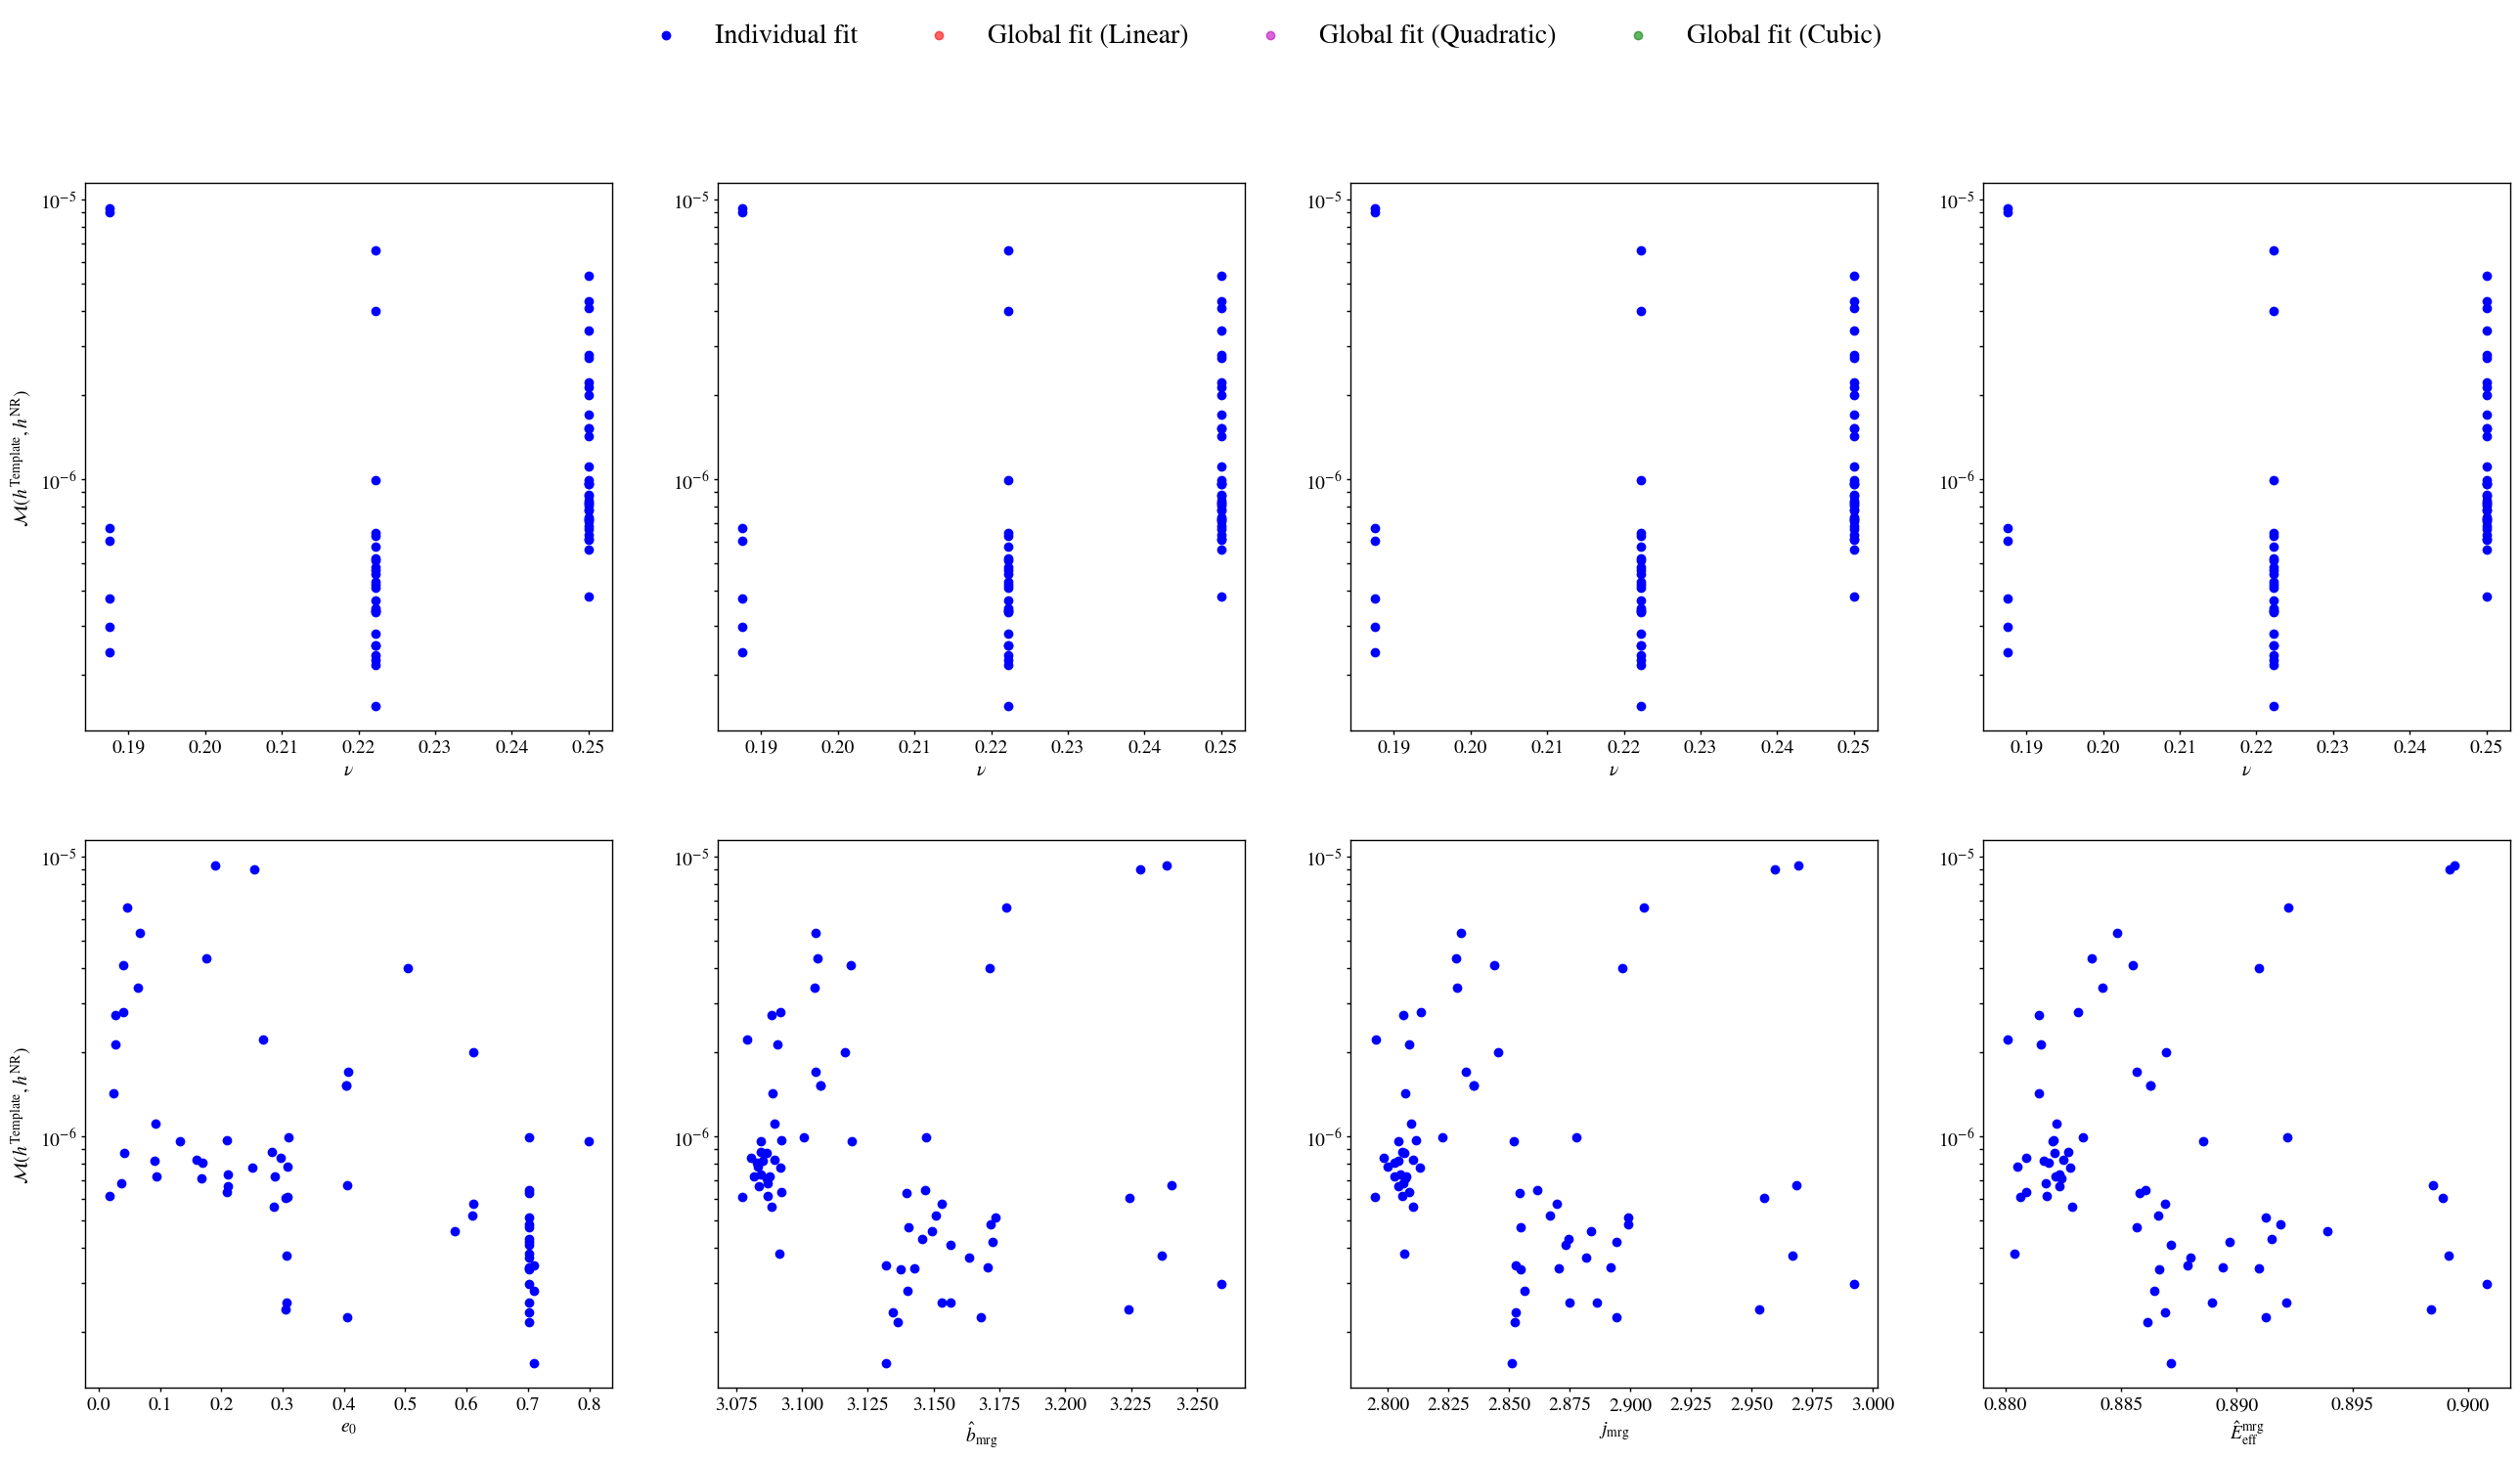

In [16]:
fig, ax = plt.subplots(2, 4, figsize=(32, 16))
ax[0,0].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,0].scatter(nu, mismatch_global_nu_ecc[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,0].scatter(nu, mismatch_global_nu_ecc[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,0].scatter(nu, mismatch_global_nu_ecc[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,0].set_xlabel('$\\nu$')
ax[0,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[0,0].set_yscale('log')
ax[1,0].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,0].set_xlabel('$e_0$')
ax[1,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[1,0].set_yscale('log')
ax[0,1].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,1].scatter(nu, mismatch_global_nu_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,1].scatter(nu, mismatch_global_nu_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,1].scatter(nu, mismatch_global_nu_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,1].set_xlabel('$\\nu$')
ax[0,1].set_yscale('log')
ax[1,1].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[1,1].scatter(bmrg, mismatch_global_nu_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,1].scatter(bmrg, mismatch_global_nu_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,1].scatter(bmrg, mismatch_global_nu_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,1].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[1,1].set_yscale('log')
ax[0,2].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,2].scatter(nu, mismatch_global_nu_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,2].scatter(nu, mismatch_global_nu_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,2].scatter(nu, mismatch_global_nu_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,2].set_xlabel('$\\nu$')
ax[0,2].set_yscale('log')
ax[1,2].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[1,2].scatter(jmrg, mismatch_global_nu_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,2].scatter(jmrg, mismatch_global_nu_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,2].scatter(jmrg, mismatch_global_nu_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,2].set_xlabel('$j_{\\rm mrg}$')
ax[1,2].set_yscale('log')
ax[0,3].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,3].scatter(nu, mismatch_global_nu_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,3].scatter(nu, mismatch_global_nu_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,3].scatter(nu, mismatch_global_nu_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,3].set_xlabel('$\\nu$')
ax[0,3].set_yscale('log')
ax[1,3].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[1,3].scatter(emrg, mismatch_global_nu_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,3].scatter(emrg, mismatch_global_nu_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,3].scatter(emrg, mismatch_global_nu_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,3].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[1,3].set_yscale('log')
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=20)
plt.show()

#### Triple Parameter

In [17]:
def mismatches_triple(parameter):
    mismatches_rit = []
    for order in [1,2,3]:
        mismatch_rit = []
        for i, sxs_id in enumerate(sxs_ids):
            try:
                mismatch_row = np.genfromtxt(f'../src/output/nc_global_fits_sxs_non-spinning/triple/nc_global_fits_{parameter}_{order}_sxs_non-spinning/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
                mismatch_rit.append(mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0])
            except:
                mismatch_rit.append(np.nan)
        mismatches_rit.append(mismatch_rit)
    return mismatches_rit

In [18]:
mismatch_global_nu_ecc_bmrg = mismatches_triple('nu_ecc_bmrg')
mismatch_global_nu_ecc_jmrg = mismatches_triple('nu_ecc_jmrg')
mismatch_global_nu_ecc_emrg = mismatches_triple('nu_ecc_emrg')
mismatch_global_nu_bmrg_jmrg = mismatches_triple('nu_bmrg_jmrg')
mismatch_global_nu_bmrg_emrg = mismatches_triple('nu_bmrg_emrg')
mismatch_global_nu_emrg_jmrg = mismatches_triple('nu_emrg_jmrg')

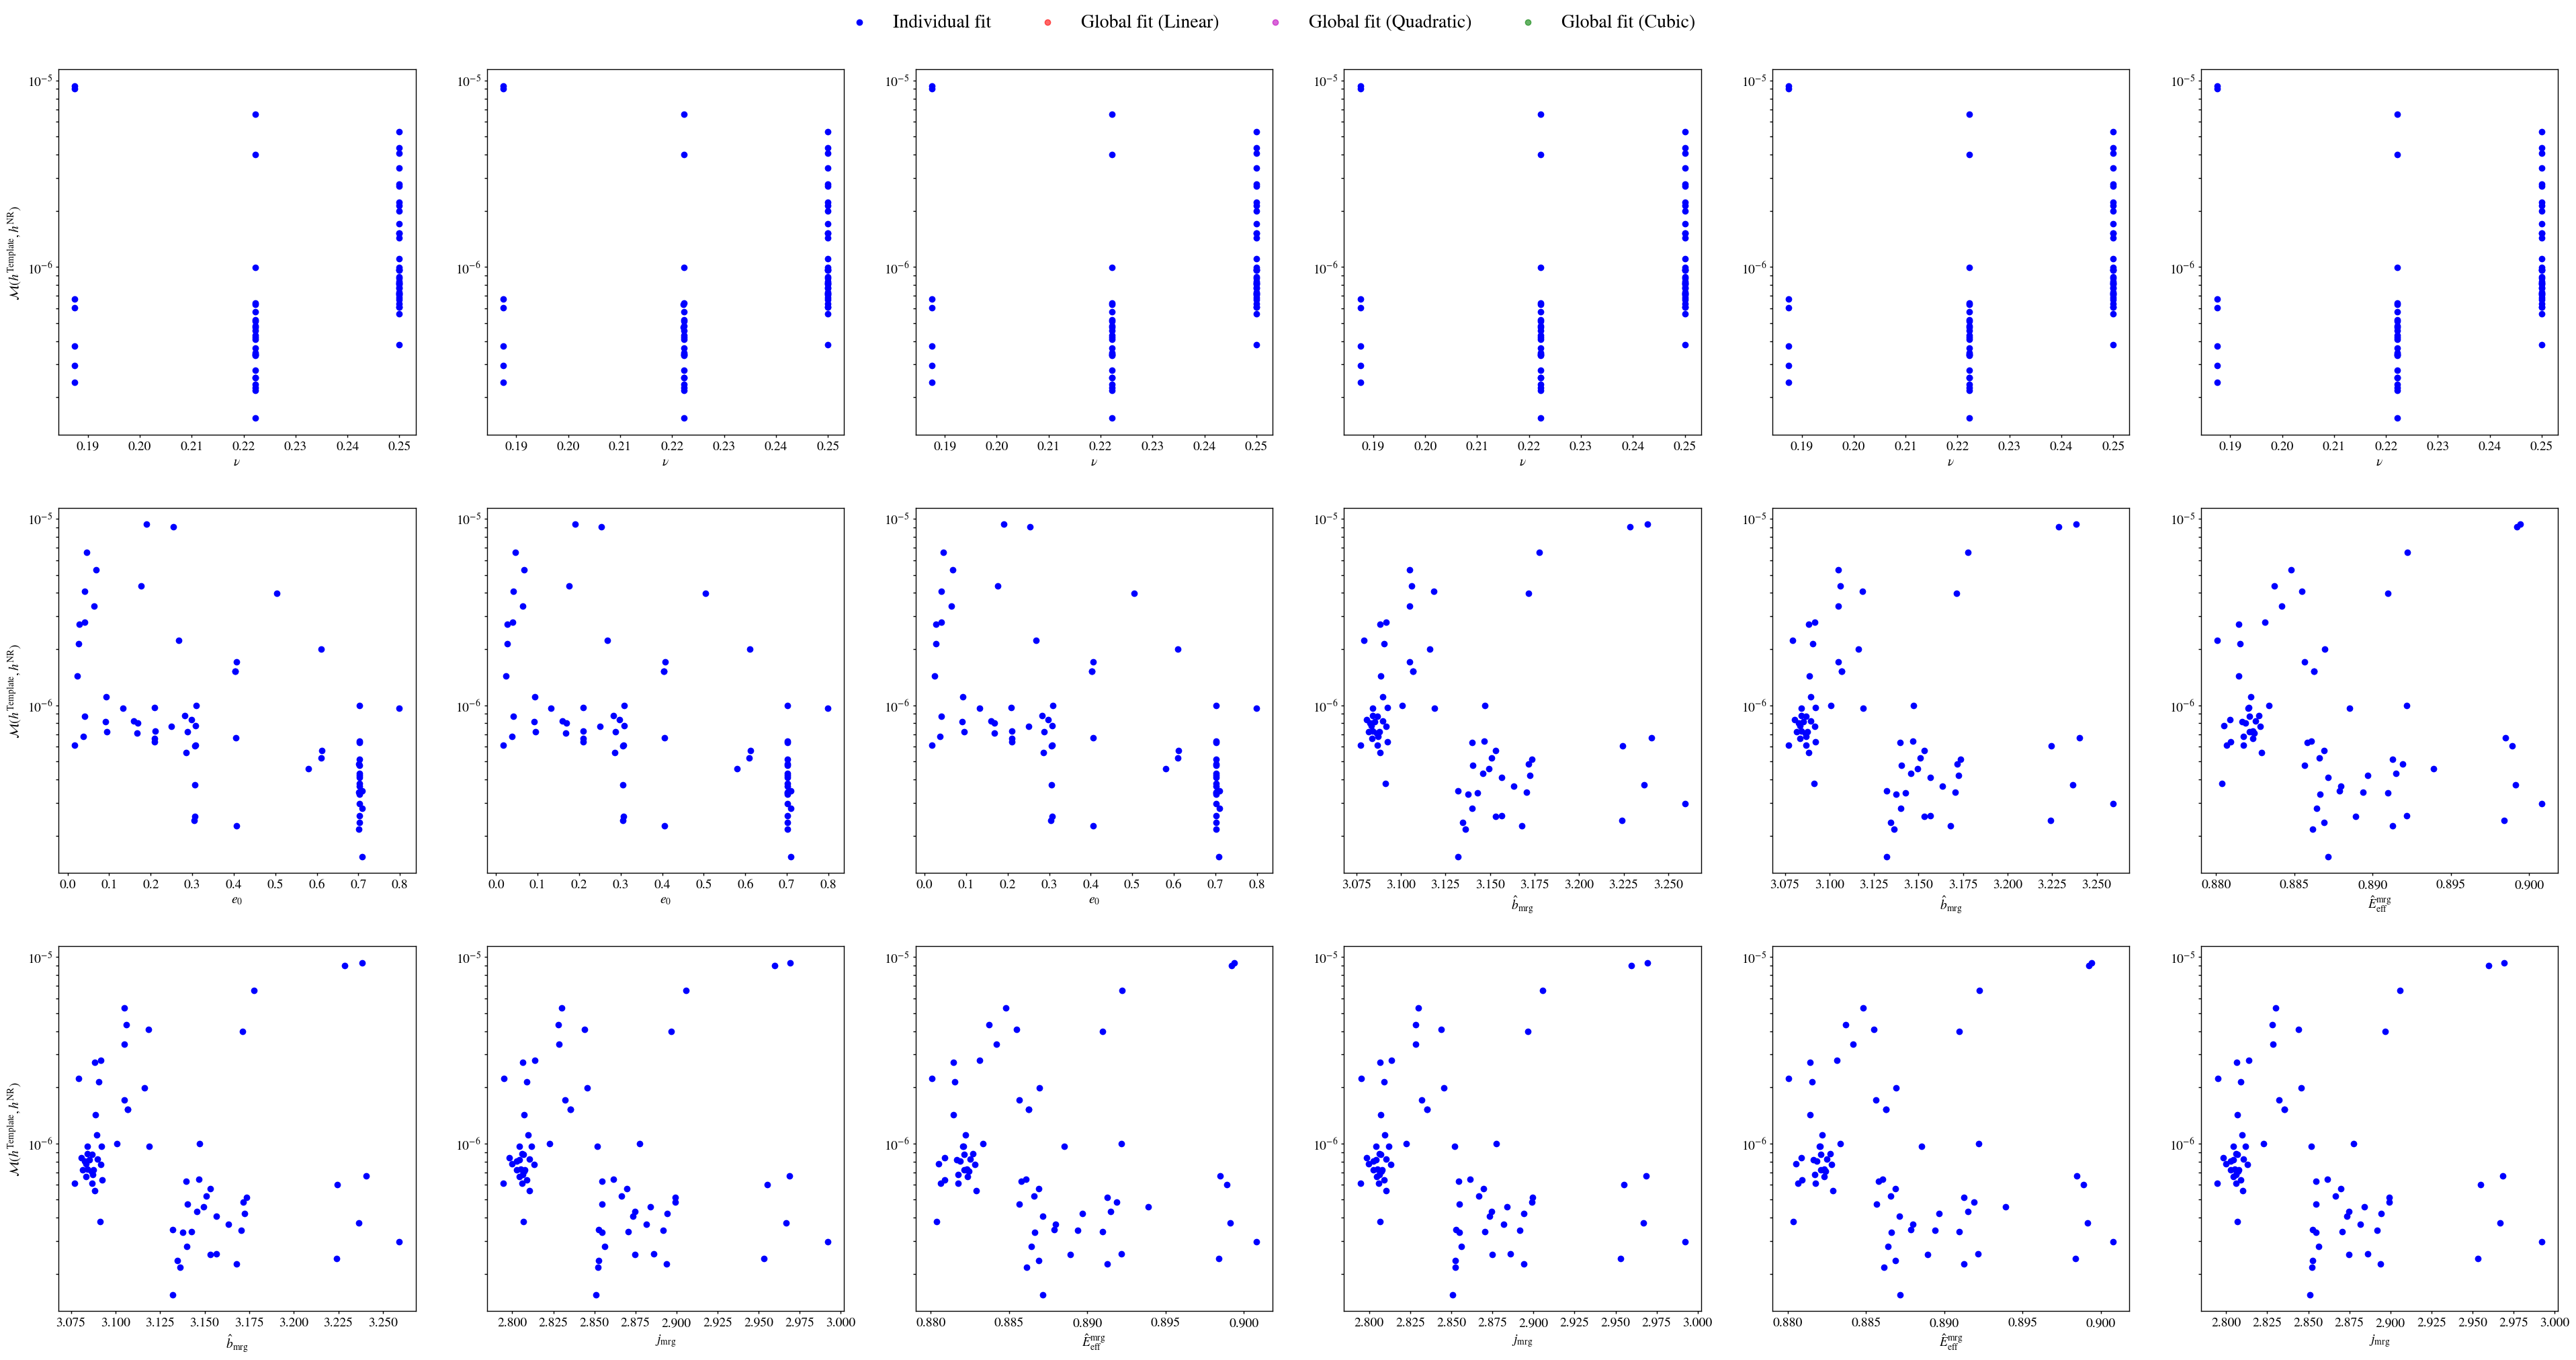

In [19]:
fig, ax = plt.subplots(3, 6, figsize=(48, 24))
ax[0,0].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,0].scatter(nu, mismatch_global_nu_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,0].scatter(nu, mismatch_global_nu_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,0].scatter(nu, mismatch_global_nu_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,0].set_xlabel('$\\nu$')
ax[0,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[0,0].set_yscale('log')
ax[1,0].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,0].scatter(ecc, mismatch_global_nu_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,0].set_xlabel('$e_0$')
ax[1,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[1,0].set_yscale('log')
ax[2,0].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[2,0].scatter(bmrg, mismatch_global_nu_ecc_bmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,0].scatter(bmrg, mismatch_global_nu_ecc_bmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,0].scatter(bmrg, mismatch_global_nu_ecc_bmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,0].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[2,0].set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax[2,0].set_yscale('log')
ax[0,1].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,1].scatter(nu, mismatch_global_nu_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,1].scatter(nu, mismatch_global_nu_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,1].scatter(nu, mismatch_global_nu_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,1].set_xlabel('$\\nu$')
ax[0,1].set_yscale('log')
ax[1,1].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[1,1].scatter(ecc, mismatch_global_nu_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,1].scatter(ecc, mismatch_global_nu_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,1].scatter(ecc, mismatch_global_nu_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,1].set_xlabel('$e_0$')
ax[1,1].set_yscale('log')
ax[2,1].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[2,1].scatter(jmrg, mismatch_global_nu_ecc_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,1].scatter(jmrg, mismatch_global_nu_ecc_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,1].scatter(jmrg, mismatch_global_nu_ecc_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,1].set_xlabel('$j_{\\rm mrg}$')
ax[2,1].set_yscale('log')
ax[0,2].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,2].scatter(nu, mismatch_global_nu_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,2].scatter(nu, mismatch_global_nu_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,2].scatter(nu, mismatch_global_nu_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,2].set_xlabel('$\\nu$')
ax[0,2].set_yscale('log')
ax[1,2].scatter(ecc, mismatch, color='b', label='Individual fit')
ax[1,2].scatter(ecc, mismatch_global_nu_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,2].scatter(ecc, mismatch_global_nu_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,2].scatter(ecc, mismatch_global_nu_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,2].set_xlabel('$e_0$')
ax[1,2].set_yscale('log')
ax[2,2].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[2,2].scatter(emrg, mismatch_global_nu_ecc_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,2].scatter(emrg, mismatch_global_nu_ecc_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,2].scatter(emrg, mismatch_global_nu_ecc_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,2].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[2,2].set_yscale('log')
ax[0,3].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,3].scatter(nu, mismatch_global_nu_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,3].scatter(nu, mismatch_global_nu_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,3].scatter(nu, mismatch_global_nu_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,3].set_xlabel('$\\nu$')
ax[0,3].set_yscale('log')
ax[1,3].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[1,3].scatter(bmrg, mismatch_global_nu_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,3].scatter(bmrg, mismatch_global_nu_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,3].scatter(bmrg, mismatch_global_nu_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,3].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[1,3].set_yscale('log')
ax[2,3].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[2,3].scatter(jmrg, mismatch_global_nu_bmrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,3].scatter(jmrg, mismatch_global_nu_bmrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,3].scatter(jmrg, mismatch_global_nu_bmrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,3].set_xlabel('$j_{\\rm mrg}$')
ax[2,3].set_yscale('log')
ax[0,4].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,4].scatter(nu, mismatch_global_nu_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,4].scatter(nu, mismatch_global_nu_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,4].scatter(nu, mismatch_global_nu_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,4].set_xlabel('$\\nu$')
ax[0,4].set_yscale('log')
ax[1,4].scatter(bmrg, mismatch, color='b', label='Individual fit')
ax[1,4].scatter(bmrg, mismatch_global_nu_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,4].scatter(bmrg, mismatch_global_nu_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,4].scatter(bmrg, mismatch_global_nu_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,4].set_xlabel('$\\hat{b}_{\\rm mrg}$')
ax[1,4].set_yscale('log')
ax[2,4].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[2,4].scatter(emrg, mismatch_global_nu_bmrg_emrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,4].scatter(emrg, mismatch_global_nu_bmrg_emrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,4].scatter(emrg, mismatch_global_nu_bmrg_emrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,4].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[2,4].set_yscale('log')
ax[0,5].scatter(nu, mismatch, color='b', label='Individual fit')
ax[0,5].scatter(nu, mismatch_global_nu_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[0,5].scatter(nu, mismatch_global_nu_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[0,5].scatter(nu, mismatch_global_nu_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[0,5].set_xlabel('$\\nu$')
ax[0,5].set_yscale('log')
ax[1,5].scatter(emrg, mismatch, color='b', label='Individual fit')
ax[1,5].scatter(emrg, mismatch_global_nu_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[1,5].scatter(emrg, mismatch_global_nu_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[1,5].scatter(emrg, mismatch_global_nu_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[1,5].set_xlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax[1,5].set_yscale('log')
ax[2,5].scatter(jmrg, mismatch, color='b', label='Individual fit')
ax[2,5].scatter(jmrg, mismatch_global_nu_emrg_jmrg[0], color='r', alpha=0.6, label='Global fit (Linear)')
ax[2,5].scatter(jmrg, mismatch_global_nu_emrg_jmrg[1], color='m', alpha=0.6, label='Global fit (Quadratic)')
ax[2,5].scatter(jmrg, mismatch_global_nu_emrg_jmrg[2], color='g', alpha=0.6, label='Global fit (Cubic)')
ax[2,5].set_xlabel('$j_{\\rm mrg}$')
ax[2,5].set_yscale('log')
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=20, bbox_to_anchor=(0.5, 0.925))
plt.show()

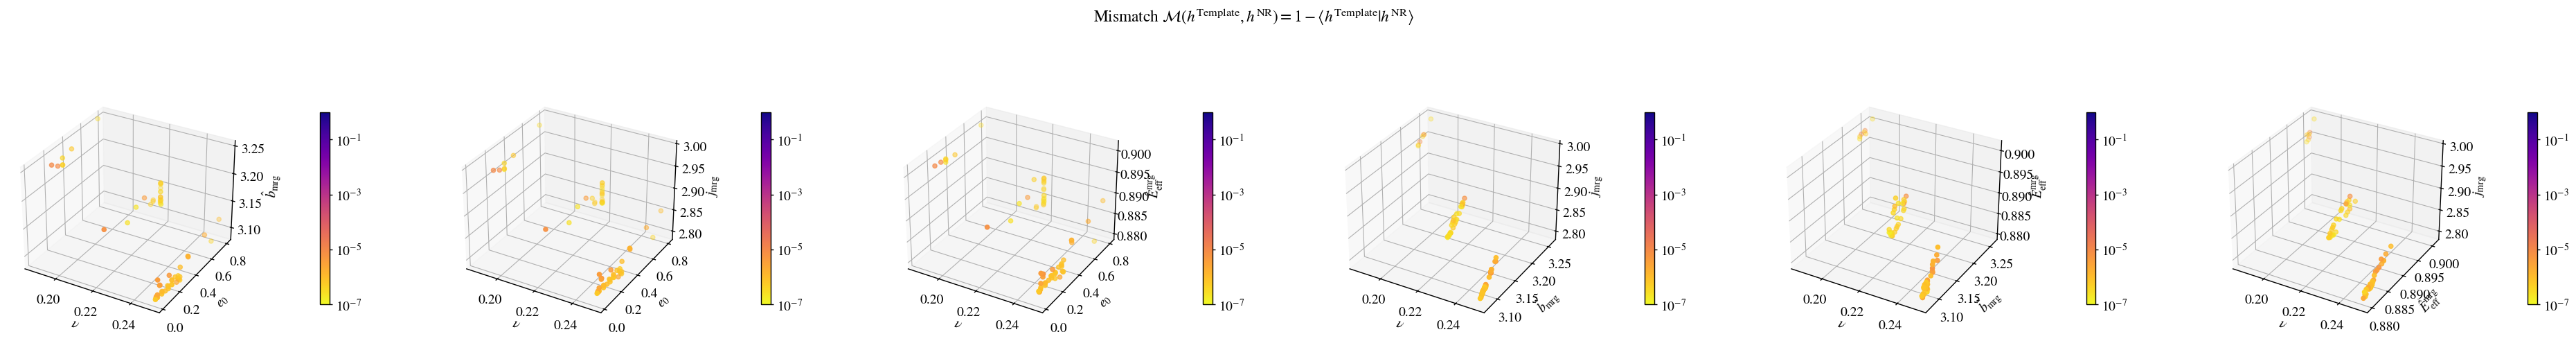

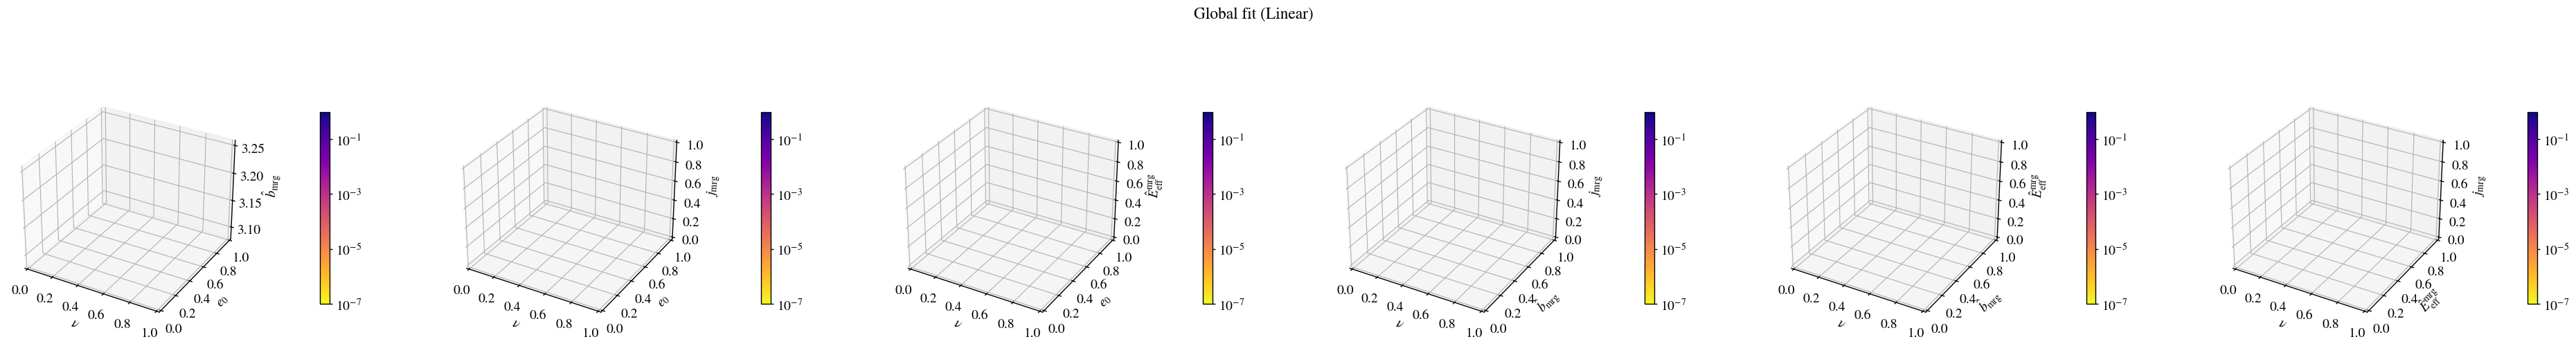

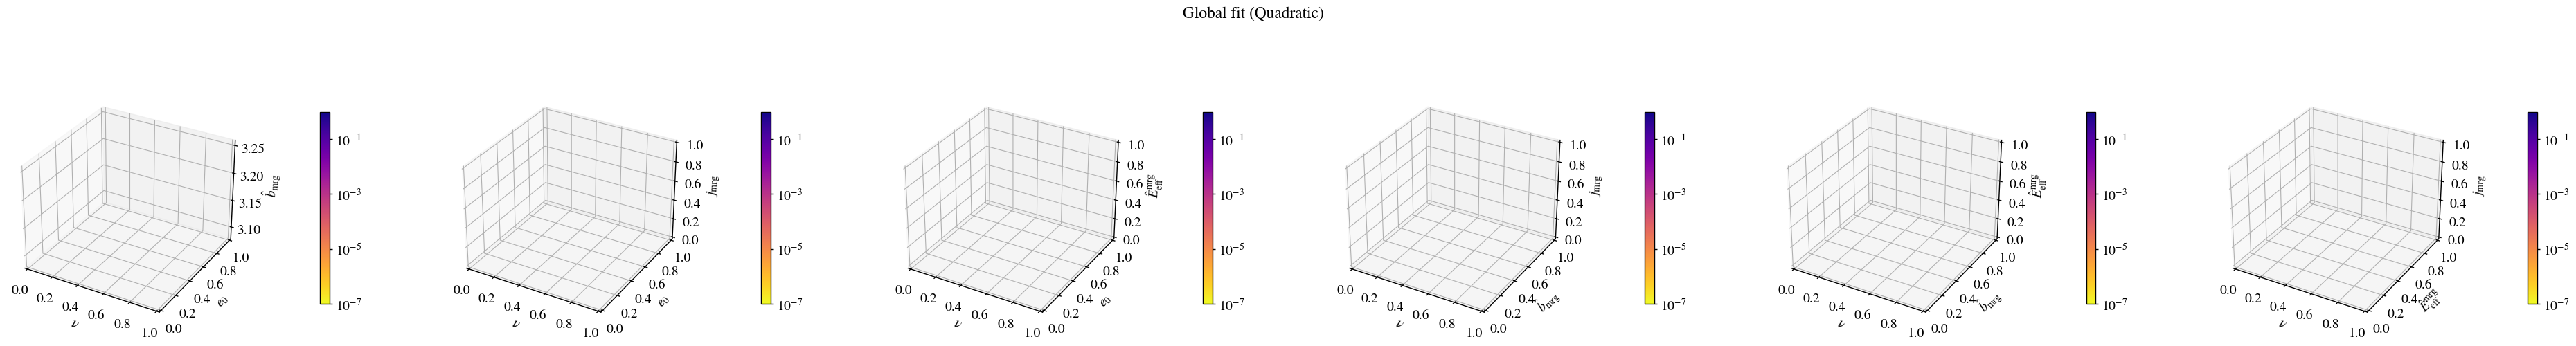

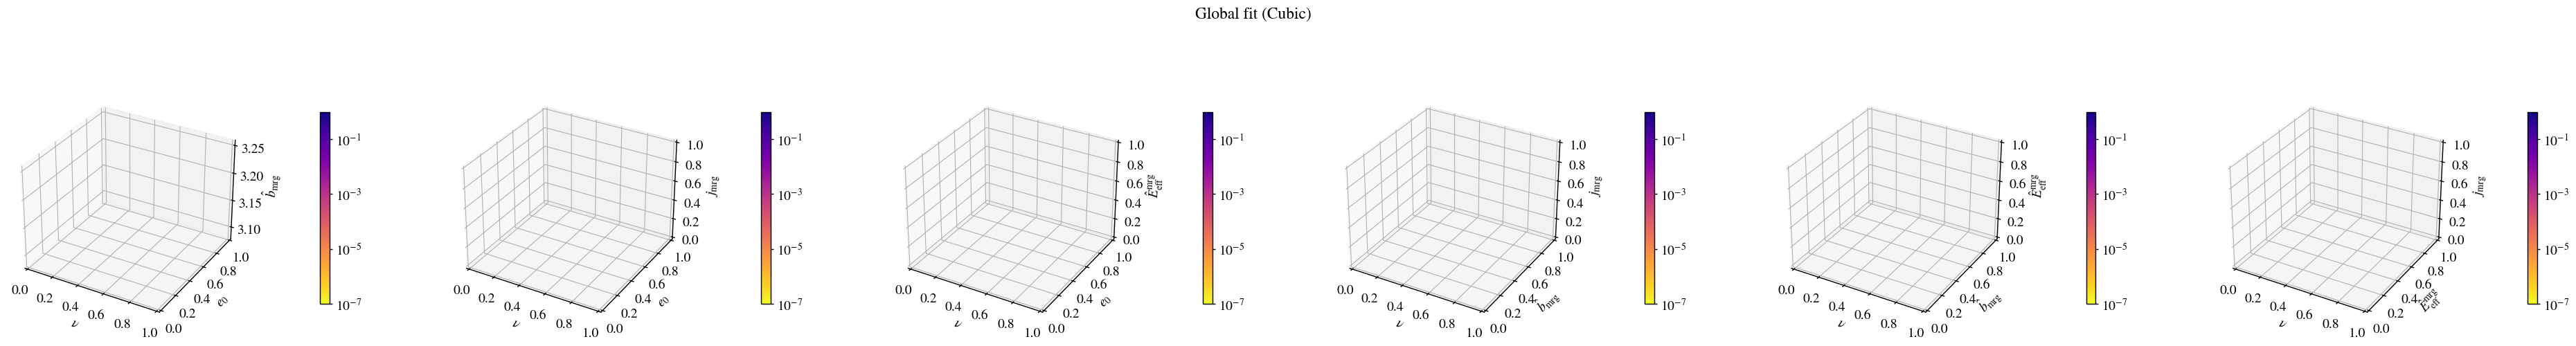

In [20]:
fig = plt.figure(figsize=(48, 6))

ax1 = fig.add_subplot(161, projection='3d')
sc1 = ax1.scatter(nu, ecc, bmrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax1.set_xlabel('$\\nu$')
ax1.set_ylabel('$e_0$')
ax1.set_zlabel('$\\hat{b}_{\\rm mrg}$')
ax1.set_zlim3d(min(bmrg), max(bmrg))
fig.colorbar(sc1, ax=ax1, shrink=0.6, location='right', pad=0.2)

ax2 = fig.add_subplot(162, projection='3d')
sc2 = ax2.scatter(nu, ecc, jmrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax2.set_xlabel('$\\nu$')
ax2.set_ylabel('$e_0$')
ax2.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc2, ax=ax2, shrink=0.6, location='right', pad=0.2)

ax3 = fig.add_subplot(163, projection='3d')
sc3 = ax3.scatter(nu, ecc, emrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax3.set_xlabel('$\\nu$')
ax3.set_ylabel('$e_0$')
ax3.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc3, ax=ax3, shrink=0.6, location='right', pad=0.2)

ax4 = fig.add_subplot(164, projection='3d')
sc4 = ax4.scatter(nu, bmrg, jmrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax4.set_xlabel('$\\nu$')
ax4.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax4.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc4, ax=ax4, shrink=0.6, location='right', pad=0.2)

ax5 = fig.add_subplot(165, projection='3d')
sc5 = ax5.scatter(nu, bmrg, emrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax5.set_xlabel('$\\nu$')
ax5.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax5.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc5, ax=ax5, shrink=0.6, location='right', pad=0.2)

ax6 = fig.add_subplot(166, projection='3d')
sc6 = ax6.scatter(nu, emrg, jmrg, c=mismatch, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax6.set_xlabel('$\\nu$')
ax6.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax6.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc6, ax=ax6, shrink=0.6, location='right', pad=0.2)

plt.suptitle('Mismatch $\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})=1-\\langle h^{\\rm Template}| h^{\\rm NR}\\rangle$')
plt.show()
plt.close()

fig = plt.figure(figsize=(48, 6))

ax1 = fig.add_subplot(161, projection='3d')
vals = mismatch_global_nu_ecc_bmrg[0]
sc1 = ax1.scatter(nu, ecc, bmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax1.set_xlabel('$\\nu$')
ax1.set_ylabel('$e_0$')
ax1.set_zlabel('$\\hat{b}_{\\rm mrg}$')
ax1.set_zlim3d(min(bmrg), max(bmrg))
fig.colorbar(sc1, ax=ax1, shrink=0.6, location='right', pad=0.2)

ax2 = fig.add_subplot(162, projection='3d')
vals = mismatch_global_nu_ecc_jmrg[0]
sc2 = ax2.scatter(nu, ecc, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax2.set_xlabel('$\\nu$')
ax2.set_ylabel('$e_0$')
ax2.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc2, ax=ax2, shrink=0.6, location='right', pad=0.2)

ax3 = fig.add_subplot(163, projection='3d')
vals = mismatch_global_nu_ecc_emrg[0]
sc3 = ax3.scatter(nu, ecc, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax3.set_xlabel('$\\nu$')
ax3.set_ylabel('$e_0$')
ax3.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc3, ax=ax3, shrink=0.6, location='right', pad=0.2)

ax4 = fig.add_subplot(164, projection='3d')
vals = mismatch_global_nu_bmrg_jmrg[0]
sc4 = ax4.scatter(nu, bmrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax4.set_xlabel('$\\nu$')
ax4.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax4.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc4, ax=ax4, shrink=0.6, location='right', pad=0.2)

ax5 = fig.add_subplot(165, projection='3d')
vals = mismatch_global_nu_bmrg_emrg[0]
sc5 = ax5.scatter(nu, bmrg, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax5.set_xlabel('$\\nu$')
ax5.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax5.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc5, ax=ax5, shrink=0.6, location='right', pad=0.2)

ax6 = fig.add_subplot(166, projection='3d')
vals = mismatch_global_nu_emrg_jmrg[0]
sc6 = ax6.scatter(nu, emrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax6.set_xlabel('$\\nu$')
ax6.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax6.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc6, ax=ax6, shrink=0.6, location='right', pad=0.2)

plt.suptitle('Global fit (Linear)')
plt.show()
plt.close()

fig = plt.figure(figsize=(48, 6))

ax1 = fig.add_subplot(161, projection='3d')
vals = mismatch_global_nu_ecc_bmrg[1]
sc1 = ax1.scatter(nu, ecc, bmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax1.set_xlabel('$\\nu$')
ax1.set_ylabel('$e_0$')
ax1.set_zlabel('$\\hat{b}_{\\rm mrg}$')
ax1.set_zlim3d(min(bmrg), max(bmrg))
fig.colorbar(sc1, ax=ax1, shrink=0.6, location='right', pad=0.2)

ax2 = fig.add_subplot(162, projection='3d')
vals = mismatch_global_nu_ecc_jmrg[1]
sc2 = ax2.scatter(nu, ecc, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax2.set_xlabel('$\\nu$')
ax2.set_ylabel('$e_0$')
ax2.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc2, ax=ax2, shrink=0.6, location='right', pad=0.2)

ax3 = fig.add_subplot(163, projection='3d')
vals = mismatch_global_nu_ecc_emrg[1]
sc3 = ax3.scatter(nu, ecc, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax3.set_xlabel('$\\nu$')
ax3.set_ylabel('$e_0$')
ax3.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc3, ax=ax3, shrink=0.6, location='right', pad=0.2)

ax4 = fig.add_subplot(164, projection='3d')
vals = mismatch_global_nu_bmrg_jmrg[1]
sc4 = ax4.scatter(nu, bmrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax4.set_xlabel('$\\nu$')
ax4.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax4.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc4, ax=ax4, shrink=0.6, location='right', pad=0.2)

ax5 = fig.add_subplot(165, projection='3d')
vals = mismatch_global_nu_bmrg_emrg[1]
sc5 = ax5.scatter(nu, bmrg, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax5.set_xlabel('$\\nu$')
ax5.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax5.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc5, ax=ax5, shrink=0.6, location='right', pad=0.2)

ax6 = fig.add_subplot(166, projection='3d')
vals = mismatch_global_nu_emrg_jmrg[1]
sc6 = ax6.scatter(nu, emrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax6.set_xlabel('$\\nu$')
ax6.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax6.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc6, ax=ax6, shrink=0.6, location='right', pad=0.2)

plt.suptitle('Global fit (Quadratic)')
plt.show()
plt.close()

fig = plt.figure(figsize=(48, 6))

ax1 = fig.add_subplot(161, projection='3d')
vals = mismatch_global_nu_ecc_bmrg[2]
sc1 = ax1.scatter(nu, ecc, bmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax1.set_xlabel('$\\nu$')
ax1.set_ylabel('$e_0$')
ax1.set_zlabel('$\\hat{b}_{\\rm mrg}$')
ax1.set_zlim3d(min(bmrg), max(bmrg))
fig.colorbar(sc1, ax=ax1, shrink=0.6, location='right', pad=0.2)

ax2 = fig.add_subplot(162, projection='3d')
vals = mismatch_global_nu_ecc_jmrg[2]
sc2 = ax2.scatter(nu, ecc, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax2.set_xlabel('$\\nu$')
ax2.set_ylabel('$e_0$')
ax2.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc2, ax=ax2, shrink=0.6, location='right', pad=0.2)

ax3 = fig.add_subplot(163, projection='3d')
vals = mismatch_global_nu_ecc_emrg[2]
sc3 = ax3.scatter(nu, ecc, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax3.set_xlabel('$\\nu$')
ax3.set_ylabel('$e_0$')
ax3.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc3, ax=ax3, shrink=0.6, location='right', pad=0.2)

ax4 = fig.add_subplot(164, projection='3d')
vals = mismatch_global_nu_bmrg_jmrg[2]
sc4 = ax4.scatter(nu, bmrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax4.set_xlabel('$\\nu$')
ax4.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax4.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc4, ax=ax4, shrink=0.6, location='right', pad=0.2)

ax5 = fig.add_subplot(165, projection='3d')
vals = mismatch_global_nu_bmrg_emrg[2]
sc5 = ax5.scatter(nu, bmrg, emrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax5.set_xlabel('$\\nu$')
ax5.set_ylabel('$\\hat{b}_{\\rm mrg}$')
ax5.set_zlabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
fig.colorbar(sc5, ax=ax5, shrink=0.6, location='right', pad=0.2)

ax6 = fig.add_subplot(166, projection='3d')
vals = mismatch_global_nu_emrg_jmrg[2]
sc6 = ax6.scatter(nu, emrg, jmrg, c=vals, cmap='plasma_r',
                  norm=LogNorm(vmin=1e-7, vmax=1))
ax6.set_xlabel('$\\nu$')
ax6.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$')
ax6.set_zlabel('$j_{\\rm mrg}$')
fig.colorbar(sc6, ax=ax6, shrink=0.6, location='right', pad=0.2)

plt.suptitle('Global fit (Cubic)')
plt.show()
plt.close()

In [ ]:
cmap = matplotlib.colormaps.get_cmap('inferno_r')
for mismatchs, key, label in zip([mismatch_global_nu[0], mismatch_global_ecc[0], mismatch_global_emrg[0], mismatch_global_bmrg[0], mismatch_global_jmrg[0]], ['nu', 'ecc', 'emrg', 'bmrg', 'jmrg'], ['$\\nu$', '$e_0$', '$\\hat{E}_{\\rm eff}^{\\rm mrg}$', '$\\hat{b}_{\\rm mrg}$', '$j_{\\rm mrg}$']):
    mismatches = np.array(mismatchs)
    fig = plt.figure(figsize=(12*1.1,7*1.1))
    ax  = fig.add_subplot(111, projection='3d')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    p = ax.scatter(nu, emrg, bmrg, c=mismatches, s=200, marker = '.', cmap=cmap, zorder=-1, norm=LogNorm(vmin=np.nanmin(mismatches[mismatches > 0]), vmax=np.nanmax(mismatches)))
    ax.scatter(nu[mismatches>1e-2], emrg[mismatches>1e-2], bmrg[mismatches>1e-2], c='k', s=100, marker = 'x', zorder=1)
    ax.set_xlabel('$\\nu$', fontsize=22, labelpad=12)
    ax.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$', fontsize=22, labelpad=12)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel('$\\hat{b}_{\\rm mrg}$', fontsize=22, labelpad=12, rotation=0)
    plt.rcParams['mathtext.fontset']  = 'stix'
    plt.rcParams['font.family']       = 'STIXGeneral'
    cb1 = fig.colorbar(p, pad=0.0, ax=ax, orientation='horizontal', shrink=0.4)
    cb1.set_label(label='$\\mathcal{M}$', fontsize=int(22*0.8))
    ax.view_init(azim=-38, elev=17)
    ax.set_title(" " * 100)
    #plt.savefig(f'nc_global_mismatches_{key}_single_nu_emrg_bmrg.pdf', bbox_inches='tight')
    plt.title(" " * 45 + f'{label}' + " " * 45)
    plt.show()

In [ ]:
cmap = matplotlib.colormaps.get_cmap('inferno_r')
for mismatchs, key, label in zip([mismatch_global_ecc_bmrg[0], mismatch_global_ecc_emrg[0], mismatch_global_ecc_jmrg[0], mismatch_global_nu_ecc[0], mismatch_global_nu_bmrg[0], mismatch_global_nu_emrg[0], mismatch_global_nu_jmrg[0], mismatch_global_bmrg_emrg[0], mismatch_global_bmrg_jmrg[0], mismatch_global_emrg_jmrg[0]], ['ecc_bmrg', 'ecc_emrg', 'ecc_jmrg', 'nu_ecc', 'nu_bmrg', 'nu_emrg', 'nu_jmrg', 'bmrg_emrg', 'bmrg_jmrg', 'emrg_jmrg'], ['$e_0, \\hat{b}_{\\rm mrg}$', '$e_0, \\hat{E}_{\\rm eff}^{\\rm mrg}$', '$e_0, j_{\\rm mrg}$', '$\\nu, e_0$', '$\\nu, \\hat{b}_{\\rm mrg}$', '$\\nu, \\hat{E}_{\\rm eff}^{\\rm mrg}$', '$\\nu, j_{\\rm mrg}$', '$\\hat{b}_{\\rm mrg}, \\hat{E}_{\\rm eff}^{\\rm mrg}$', '$\\hat{b}_{\\rm mrg}, j_{\\rm mrg}$', '$\\hat{E}_{\\rm eff}^{\\rm mrg}, j_{\\rm mrg}$']):
    mismatches = np.array(mismatchs)
    fig = plt.figure(figsize=(12*1.1,7*1.1))
    ax  = fig.add_subplot(111, projection='3d')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    p = ax.scatter(nu, emrg, bmrg, c=mismatches, s=200, marker = '.', cmap=cmap, zorder=-1, norm=LogNorm(vmin=np.nanmin(mismatches[mismatches > 0]), vmax=np.nanmax(mismatches)))
    ax.scatter(nu[mismatches>1e-2], emrg[mismatches>1e-2], bmrg[mismatches>1e-2], c='k', s=100, marker = 'x', zorder=1)
    ax.set_xlabel('$\\nu$', fontsize=22, labelpad=12)
    ax.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$', fontsize=22, labelpad=12)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel('$\\hat{b}_{\\rm mrg}$', fontsize=22, labelpad=12, rotation=0)
    plt.rcParams['mathtext.fontset']  = 'stix'
    plt.rcParams['font.family']       = 'STIXGeneral'
    cb1 = fig.colorbar(p, pad=0.0, ax=ax, orientation='horizontal', shrink=0.4)
    cb1.set_label(label='$\\mathcal{M}$', fontsize=int(22*0.8))
    ax.view_init(azim=-38, elev=17)
    ax.set_title(" " * 100)
    #plt.savefig(f'nc_global_mismatches_{key}_dual_nu_emrg_bmrg.pdf', bbox_inches='tight')
    plt.title(" " * 42 + f'{label}' + " " * 42)
    plt.show()

In [ ]:
cmap = matplotlib.colormaps.get_cmap('inferno_r')
for mismatchs, key, label in zip([mismatch_global_nu_ecc_bmrg[0], mismatch_global_nu_ecc_emrg[0], mismatch_global_nu_ecc_jmrg[0], mismatch_global_nu_bmrg_jmrg[0], mismatch_global_nu_bmrg_emrg[0], mismatch_global_nu_emrg_jmrg[0]], ['nu_ecc_bmrg', 'nu_ecc_emrg', 'nu_ecc_jmrg', 'nu_bmrg_jmrg', 'nu_bmrg_emrg', 'nu_emrg_jmrg'], ['$\\nu, e_0, \\hat{b}_{\\rm mrg}$', '$\\nu, e_0, \\hat{E}_{\\rm eff}^{\\rm mrg}$', '$\\nu, e_0, j_{\\rm mrg}$', '$\\nu, \\hat{b}_{\\rm mrg}, j_{\\rm mrg}$', '$\\nu, \\hat{b}_{\\rm mrg}, \\hat{E}_{\\rm eff}^{\\rm mrg}$', '$\\nu, \\hat{E}_{\\rm eff}^{\\rm mrg}, j_{\\rm mrg}$']):
    mismatches = np.array(mismatchs)
    fig = plt.figure(figsize=(12*1.1,7*1.1))
    ax  = fig.add_subplot(111, projection='3d')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    p = ax.scatter(nu, emrg, bmrg, c=mismatches, s=200, marker = '.', cmap=cmap, zorder=-1, norm=LogNorm(vmin=np.nanmin(mismatches[mismatches > 0]), vmax=np.nanmax(mismatches)))
    ax.scatter(nu[mismatches>1e-2], emrg[mismatches>1e-2], bmrg[mismatches>1e-2], c='k', s=100, marker = 'x', zorder=1)
    ax.set_xlabel('$\\nu$', fontsize=22, labelpad=12)
    ax.set_ylabel('$\\hat{E}_{\\rm eff}^{\\rm mrg}$', fontsize=22, labelpad=12)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel('$\\hat{b}_{\\rm mrg}$', fontsize=22, labelpad=12, rotation=0)
    plt.rcParams['mathtext.fontset']  = 'stix'
    plt.rcParams['font.family']       = 'STIXGeneral'
    cb1 = fig.colorbar(p, pad=0.0, ax=ax, orientation='horizontal', shrink=0.4)
    cb1.set_label(label='$\\mathcal{M}$', fontsize=int(22*0.8))
    ax.view_init(azim=-38, elev=17)
    ax.set_title(" " * 100)
    #plt.savefig(f'nc_global_mismatches_{key}_triple_nu_emrg_bmrg.pdf', bbox_inches='tight')
    plt.title(" " * 40 + f'{label}' + " " * 40)
    plt.show()